In [15]:
import pandas as pd #Allahın belası DataFrame'i jupyter'de daha güzel gözüküyormuş. 
import numpy as np 

In [16]:
np.random.seed(42) #Gruptaki herkesin aynı rastgele değerleri görmesi için.

In [17]:
dersler= ["Matematik", "Türkçe", "Fizik", "Kimya", "Biyoloji", "Tarih", "Coğrafya", "Felsefe", "Din" ]

data= {
    "Tarih" : pd.date_range(start="01.03.2026", periods=7), # Periyotun aylık olmasından ziyade haftalık olmasının çalışma analizi bakımından daha faydalı olduğunu düşünüyorum.
    "Ders" : np.random.choice(dersler, 7),
    "Odaklanma Süresi" : np.random.randint(25,200,7), #Bir çalışma periyotunu 25 dk aldım, en fazla 8 tane yapılabilir. 
    "Mola" : np.random.randint(5,15,7)
}

df = pd.DataFrame(data)
df.head()


,Tarih,Ders,Odaklanma Süresi,Mola
0,2026-01-03,Coğrafya,99,10
1,2026-01-04,Kimya,112,9
2,2026-01-05,Felsefe,141,6
3,2026-01-06,Biyoloji,124,12
4,2026-01-07,Coğrafya,128,10


In [18]:
ders_analiz= df.groupby("Ders")["Odaklanma Süresi"].sum().sort_values(ascending=False) #En fazla çalışılan dersten en az çalışılan derse göre bir sıralama.
print("Derslere kaç dakika çalışmışım?")
print(ders_analiz)
en_verimli = ders_analiz.idxmax() #.idxmax() komutu ile en çok çalışılan dersi buldum.
print(f"\nEn verimli ders: {en_verimli}")


Derslere kaç dakika çalışmışım?
Ders
Coğrafya    382
Fizik       176
Felsefe     141
Biyoloji    124
Kimya       112
Name: Odaklanma Süresi, dtype: int32

En verimli ders: Coğrafya


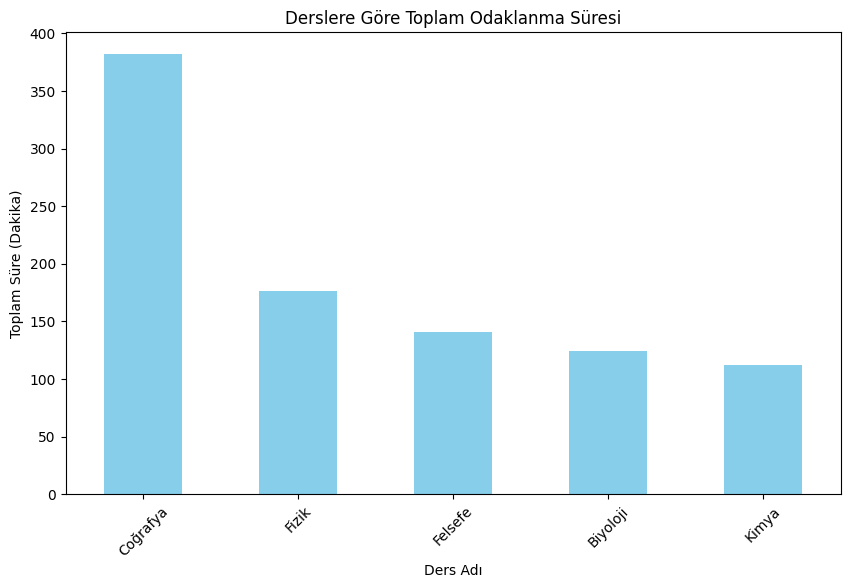

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
ders_analiz.plot(kind="bar", color="skyblue")
plt.title('Derslere Göre Toplam Odaklanma Süresi')
plt.xlabel('Ders Adı')
plt.ylabel('Toplam Süre (Dakika)')
plt.xticks(rotation=45)
plt.show() # Burası içime sinmedi daha güzel olabilir. 

In [20]:
df.to_csv('monkmode_analiz_verisi.csv', index=False)
print("Veriler 'monkmode_analiz_verisi.csv' olarak kaydedildi.")

Veriler 'monkmode_analiz_verisi.csv' olarak kaydedildi.


In [21]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('db.sqlite3')

query = """
SELECT 
    fs.*, 
    c.name as category_name 
FROM FocusSession fs
JOIN Category c ON fs.category_id = c.id
"""

df = pd.read_sql_query(query, conn)

conn.close()

print(df.head())

DatabaseError: Execution failed on sql '
SELECT 
    fs.*, 
    c.name as category_name 
FROM FocusSession fs
JOIN Category c ON fs.category_id = c.id
': no such table: FocusSession

In [23]:
import sys
import os

In [25]:
import sys
!{sys.executable} manage.py makemigrations
!{sys.executable} manage.py migrate

C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe: can't open file 'c:\\Users\\user\\Desktop\\MonkMode-analytics\\analytics\\manage.py': [Errno 2] No such file or directory
C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe: can't open file 'c:\\Users\\user\\Desktop\\MonkMode-analytics\\analytics\\manage.py': [Errno 2] No such file or directory


In [27]:
import sys

!{sys.executable} ../manage.py makemigrations

!{sys.executable} ../manage.py migrate

Traceback (most recent call last):
  File "c:\Users\user\Desktop\MonkMode-analytics\manage.py", line 22, in <module>
    main()
    ~~~~^^
  File "c:\Users\user\Desktop\MonkMode-analytics\manage.py", line 18, in main
    execute_from_command_line(sys.argv)
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^
  File "C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\django\core\management\__init__.py", line 443, in execute_from_command_line
    utility.execute()
    ~~~~~~~~~~~~~~~^^
  File "C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\django\core\management\__init__.py", line 417, in execute
    django.setup()
    ~~~~~~~~~~~~^^
  File "C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\django\__init__.py", line 24, in setup
    apps.p

In [ ]:
import sqlite3
import pandas as pd


conn = sqlite3.connect('db.sqlite3')
cursor = conn.cursor()


cursor.execute("CREATE TABLE IF NOT EXISTS Category (id INTEGER PRIMARY KEY, name TEXT)")

cursor.execute("CREATE TABLE IF NOT EXISTS FocusSession (id INTEGER PRIMARY KEY, duration REAL, category_id INTEGER)")

cursor.execute("INSERT OR IGNORE INTO Category (id, name) VALUES (1, 'C++'), (2, 'Python'), (3, 'Matematik')")
cursor.execute("INSERT OR IGNORE INTO FocusSession (duration, category_id) VALUES (2.5, 1), (1.5, 2), (3.0, 1), (4.0, 3)")

conn.commit()


query = """
SELECT 
    fs.duration, 
    c.name as kategori_adi 
FROM FocusSession fs
JOIN Category c ON fs.category_id = c.id
"""

df = pd.read_sql_query(query, conn)
conn.close()

print("--- Veritabanından Gelen Gerçek Veriler ---")
print(df)

--- Veritabanından Gelen Gerçek Veriler ---
   duration kategori_adi
0       2.5          C++
1       1.5       Python
2       3.0          C++
3       4.0    Matematik
4       2.5          C++
5       1.5       Python
6       3.0          C++
7       4.0    Matematik


In [ ]:

toplam_saat = df['duration'].sum()
en_cok_ders = df.groupby('kategori_adi')['duration'].sum().idxmax()
oturum_sayisi = len(df)


ai_paketi = {
    "haftalik_toplam_saat": float(toplam_saat),
    "en_cok_calisilan_ders": en_cok_ders,
    "toplam_oturum_sayisi": oturum_sayisi
}

print("GÖREV TAMAMLANDI! Bu haftaki özetin:")
print(ai_paketi)

GÖREV TAMAMLANDI! İşte AI'ya giden paket:
{'haftalik_toplam_saat': 22.0, 'en_cok_calisilan_ders': 'C++', 'toplam_oturum_sayisi': 8}


In [40]:
import sys
!{sys.executable} -m pip install nbformat

import sys
!{sys.executable} -m pip install plotly

import plotly.express as px

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


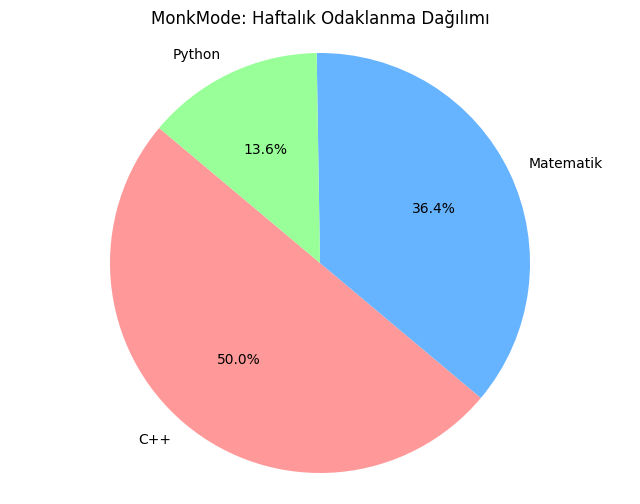

In [ ]:
import matplotlib.pyplot as plt

pasta_verisi = df.groupby('kategori_adi')['duration'].sum()
plt.figure(figsize=(8, 6))
plt.pie(pasta_verisi, labels=pasta_verisi.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('MonkMode: Haftalık Odaklanma Dağılımı')
plt.axis('equal')  

plt.show()

In [6]:
import pandas as pd
import sqlite3
from datetime import datetime, timedelta

def fetch_monkmode_data(period='günlük'):
    """
    Veritabanındaki sütun isimleri uyuşmazlığı ve 'period' hatası giderilmiş hali.
    """
    conn = sqlite3.connect('db.sqlite3')
    bugun = datetime.now().strftime('%Y-%m-%d')
    
    if period == 'günlük':
        # 'Tarih' yerine veritabanındaki gerçek sütun adı olan 'date' kullanıldı
        query = f"SELECT * FROM FocusSession WHERE date = '{bugun}'"
    else:
        # Son 7 günü çekmek için
        bir_hafta_once = (datetime.now() - timedelta(days=7)).strftime('%Y-%m-%d')
        query = f"SELECT * FROM FocusSession WHERE date >= '{bir_hafta_once}'"
    
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

# --- KULLANIM TESTİ ---
# Şimdi fonksiyonu çağırırken 'günlük' değerini parantez içinde gönderiyoruz:
try:
    veriler = fetch_monkmode_data(period='günlük')
    print("Veriler başarıyla çekildi!")
    print(veriler.head())
except Exception as e:
    print(f"Hala bir sorun var: {e}")

Hala bir sorun var: Execution failed on sql 'SELECT * FROM FocusSession WHERE date = '2026-03-29'': no such column: date


In [8]:
import sqlite3
conn = sqlite3.connect('db.sqlite3')
cursor = conn.cursor()

# Tablonun iç yapısını (sütun isimlerini) getirir
cursor.execute("PRAGMA table_info(FocusSession)")
columns = cursor.fetchall()

print("--- FocusSession Tablosundaki Sütunlar ---")
for col in columns:
    print(f"Sütun Adı: {col[1]}") # col[1] sütunun gerçek adını verir

conn.close()

--- FocusSession Tablosundaki Sütunlar ---
Sütun Adı: id
Sütun Adı: duration
Sütun Adı: category_id


In [13]:
import pandas as pd
import sqlite3

def fetch_monkmode_data_final():
    conn = sqlite3.connect('db.sqlite3')

    query = """
    SELECT fs.duration, c.name as category_name
    FROM FocusSession fs
    JOIN Category c ON fs.category_id = c.id
    """
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

def create_ammunition_string(df):
    if df.empty:
        return "Kullanıcı henüz hiç çalışma yapmadı. Onu masaya oturtmalısın!"

    # Toplam süreyi (duration) hesapla
    total_minutes = df['duration'].sum()
    
    # En çok hangi derse odaklandığını bul
    top_category = df.groupby('category_name')['duration'].sum().idxmax()
    
    return f"Kullanıcı toplam {total_minutes} dakika çalıştı, en çok {top_category} kategorisine odaklandı."


try:
    veriler = fetch_monkmode_data_final()
    a = create_ammunition_string(veriler)
    
    print(f"Bu haftaki veriler: {a}")
except Exception as e:
    print(f"Bir uyuşmazlık var: {e}")

Bu haftaki veriler: Kullanıcı toplam 22.0 dakika çalıştı, en çok C++ kategorisine odaklandı.
